# Discoverathon 2026

## Problem Statement 1
**Predicting Drug Combination Activity**

### Objective
Explore and understand the NCI-ALMANAC dataset before preprocessing and model development.

### Author
Alupana Balaji Reddy

### Date
03 August 2026

In [1]:
# ZIP file handling
import zipfile

# Path handling
from pathlib import Path

# Data analysis
import pandas as pd
import numpy as np

# Plots
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Project folder
PROJECT_ROOT = Path("..")

# Raw data folder
DATA_DIR = PROJECT_ROOT / "data" / "raw"

# ZIP file
ZIP_FILE = DATA_DIR / "ComboDrugGrowth_Nov2017.zip"

print("ZIP file location:")
print(ZIP_FILE)

print("\nDoes the file exist?")
print(ZIP_FILE.exists())

ZIP file location:
../data/raw/ComboDrugGrowth_Nov2017.zip

Does the file exist?
True


In [3]:
# Open the ZIP file
with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:

    # Get list of all files inside the ZIP
    file_list = zip_ref.namelist()

# Print summary
print(f"Number of files inside ZIP: {len(file_list)}\n")

# Print each file name
for file in file_list:
    print(file)

Number of files inside ZIP: 1

ComboDrugGrowth_Nov2017.csv


In [4]:
# Read the CSV file directly from the ZIP archive

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:

    with zip_ref.open("ComboDrugGrowth_Nov2017.csv") as file:

        df = pd.read_csv(file)

print("Dataset loaded successfully!")

/tmp/ipykernel_1906822/3500262529.py:7: DtypeWarning: Columns (0: PLATE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Dataset loaded successfully!


In [5]:
# Number of rows and columns

print("Dataset Shape")

rows, columns = df.shape

print(f"Rows    : {rows:,}")
print(f"Columns : {columns}")

Dataset Shape
Rows    : 3,686,475
Columns : 29


In [6]:
# Display first 5 rows

df.head()

,COMBODRUGSEQ,SCREENER,STUDY,TESTDATE,PLATE,PANELNBR,CELLNBR,PREFIX1,NSC1,SAMPLE1,CONCINDEX1,CONC1,CONCUNIT1,PREFIX2,NSC2,SAMPLE2,CONCINDEX2,CONC2,CONCUNIT2,PERCENTGROWTH,PERCENTGROWTHNOTZ,TESTVALUE,CONTROLVALUE,TZVALUE,EXPECTEDGROWTH,SCORE,VALID,PANEL,CELLNAME
0,260496,FG,PZUT00156_86_01_T72,06/23/2011,786-0_1_T72,9,18,S,752,37,1,1.000000e-07,M,S,3088.0,10.0,1,0.000001,M,85.979,88.159,332168.0,376781.548,58592.854,90.342,4.0,Y,Renal Cancer,786-0
1,260497,FG,PZUT00156_86_01_T72,06/23/2011,786-0_1_T72,9,18,S,752,37,1,1.000000e-07,M,S,3088.0,10.0,2,0.000010,M,100.903,100.763,379656.0,376781.548,58592.854,87.130,-14.0,Y,Renal Cancer,786-0
2,260498,FG,PZUT00156_86_01_T72,06/23/2011,786-0_1_T72,9,18,S,752,37,1,1.000000e-07,M,S,3088.0,10.0,3,0.000100,M,14.147,27.498,103608.0,376781.548,58592.854,12.739,-1.0,Y,Renal Cancer,786-0
3,260499,FG,PZUT00156_86_01_T72,06/23/2011,786-0_1_T72,9,18,S,752,37,2,1.000000e-06,M,S,3088.0,10.0,1,0.000001,M,71.268,75.736,285360.0,376781.548,58592.854,76.397,5.0,Y,Renal Cancer,786-0
4,260500,FG,PZUT00156_86_01_T72,06/23/2011,786-0_1_T72,9,18,S,752,37,2,1.000000e-06,M,S,3088.0,10.0,2,0.000010,M,89.278,90.945,342664.0,376781.548,58592.854,73.681,-16.0,Y,Renal Cancer,786-0


In [7]:
df.columns.tolist()

['COMBODRUGSEQ',
 'SCREENER',
 'STUDY',
 'TESTDATE',
 'PLATE',
 'PANELNBR',
 'CELLNBR',
 'PREFIX1',
 'NSC1',
 'SAMPLE1',
 'CONCINDEX1',
 'CONC1',
 'CONCUNIT1',
 'PREFIX2',
 'NSC2',
 'SAMPLE2',
 'CONCINDEX2',
 'CONC2',
 'CONCUNIT2',
 'PERCENTGROWTH',
 'PERCENTGROWTHNOTZ',
 'TESTVALUE',
 'CONTROLVALUE',
 'TZVALUE',
 'EXPECTEDGROWTH',
 'SCORE',
 'VALID',
 'PANEL',
 'CELLNAME']

In [8]:
df.dtypes

COMBODRUGSEQ           int64
SCREENER                 str
STUDY                    str
TESTDATE                 str
PLATE                 object
PANELNBR               int64
CELLNBR                int64
PREFIX1                  str
NSC1                   int64
SAMPLE1                int64
CONCINDEX1             int64
CONC1                float64
CONCUNIT1                str
PREFIX2                  str
NSC2                 float64
SAMPLE2              float64
CONCINDEX2             int64
CONC2                float64
CONCUNIT2                str
PERCENTGROWTH        float64
PERCENTGROWTHNOTZ    float64
TESTVALUE            float64
CONTROLVALUE         float64
TZVALUE              float64
EXPECTEDGROWTH       float64
SCORE                float64
VALID                    str
PANEL                    str
CELLNAME                 str
dtype: object

In [9]:
df["NSC2"].isnull().sum()

np.int64(812961)

In [10]:
df["SAMPLE2"].isnull().sum()

np.int64(812961)

In [11]:
df["SCORE"].describe()

count    2.871444e+06
mean    -2.380036e+00
std      1.245127e+01
min     -2.270000e+02
25%     -8.000000e+00
50%     -2.000000e+00
75%      3.000000e+00
max      1.990000e+02
Name: SCORE, dtype: float64

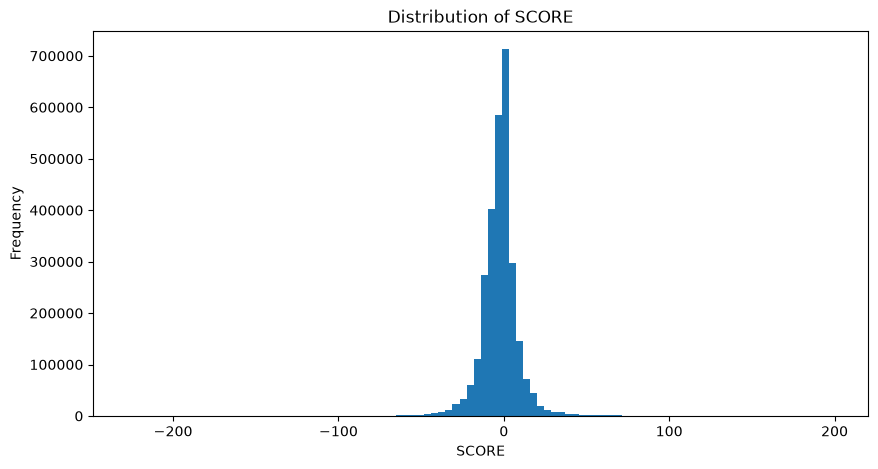

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df["SCORE"].dropna(), bins=100)
plt.title("Distribution of SCORE")
plt.xlabel("SCORE")
plt.ylabel("Frequency")
plt.show()

In [13]:
print("Unique Drug 1:", df["NSC1"].nunique())
print("Unique Drug 2:", df["NSC2"].nunique())

all_drugs = set(df["NSC1"].dropna()).union(set(df["NSC2"].dropna()))
print("Total Unique Drugs:", len(all_drugs))

Unique Drug 1: 105
Unique Drug 2: 104
Total Unique Drugs: 105


In [14]:
print("Unique Cell Lines:", df["CELLNAME"].nunique())

df["CELLNAME"].value_counts().head(20)

Unique Cell Lines: 61


CELLNAME
HCT-116        63934
NCI-H23        63315
NCI/ADR-RES    63261
ACHN           63198
MCF7           62895
HCT-15         62886
OVCAR-5        62874
SW-620         62820
SF-268         62799
SK-MEL-28      62787
SNB-19         62685
OVCAR-8        62679
SK-OV-3        62661
HT29           62568
U251           62565
A498           62541
SN12C          62523
UACC-257       62521
TK-10          62514
DU-145         62442
Name: count, dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df[df["NSC2"].isnull()]["SCORE"].isnull().sum()

np.int64(812961)

In [17]:
df[df["NSC2"].isnull()].shape

(812961, 29)

# Section 1: Understanding the Dataset

## Objective

The objective of this section is to understand the structure of the NCI-ALMANAC dataset before performing any preprocessing or machine learning.

In [18]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 3686475
Number of Columns : 29


## Observation

The dataset contains 3,686,475 experimental records and 29 columns.

The dataset is sufficiently large for machine learning and requires preprocessing before model development.

# Section 2 : Dataset Columns

The following code lists all available columns in the dataset.

In [19]:
df.columns.tolist()

['COMBODRUGSEQ',
 'SCREENER',
 'STUDY',
 'TESTDATE',
 'PLATE',
 'PANELNBR',
 'CELLNBR',
 'PREFIX1',
 'NSC1',
 'SAMPLE1',
 'CONCINDEX1',
 'CONC1',
 'CONCUNIT1',
 'PREFIX2',
 'NSC2',
 'SAMPLE2',
 'CONCINDEX2',
 'CONC2',
 'CONCUNIT2',
 'PERCENTGROWTH',
 'PERCENTGROWTHNOTZ',
 'TESTVALUE',
 'CONTROLVALUE',
 'TZVALUE',
 'EXPECTEDGROWTH',
 'SCORE',
 'VALID',
 'PANEL',
 'CELLNAME']

## Observation

The dataset contains information related to:

- Drug 1
- Drug 2
- Cell line
- Drug concentrations
- Experimental measurements
- Combination score

# Section 3 : Understanding Important Columns

In this section, we identify the most important columns required for building a machine learning model.

## Data Dictionary

| Column | What I Observed | Used in ML? |
|---------|-----------------|-------------|
| NSC1 | Drug 1 Identifier | Yes |
| NSC2 | Drug 2 Identifier | Yes |
| CELLNAME | Cancer Cell Line | Yes |
| SCORE | Drug Combination Score | Target |
| PANEL | Cancer Panel | Maybe |
| VALID | Experiment Status | Need Investigation |
| CONC1 | Drug 1 Concentration | Maybe |
| CONC2 | Drug 2 Concentration | Maybe |

In [20]:
df["VALID"].value_counts(dropna=False)

VALID
Y    3686475
Name: count, dtype: int64

## Observation

(To be completed after looking at the output.)

In [21]:
df["PANEL"].value_counts()

PANEL
Non-Small Cell Lung Cancer    554157
Melanoma                      531922
Renal Cancer                  497351
Colon Cancer                  437857
Ovarian Cancer                435512
Breast Cancer                 373161
CNS Cancer                    368334
Leukemia                      363452
Prostate Cancer               124729
Name: count, dtype: int64

In [22]:
df.groupby("PANEL")["CELLNAME"].nunique()

PANEL
Breast Cancer                 6
CNS Cancer                    7
Colon Cancer                  7
Leukemia                      6
Melanoma                      9
Non-Small Cell Lung Cancer    9
Ovarian Cancer                7
Prostate Cancer               2
Renal Cancer                  8
Name: CELLNAME, dtype: int64

In [23]:
df["VALID"].value_counts(dropna=False)

VALID
Y    3686475
Name: count, dtype: int64

### Observation

The `VALID` column contains only one value (`Y`).

### Interpretation

All experiments in the dataset are marked as valid. Therefore, no filtering based on the `VALID` column is required during preprocessing.

In [24]:
df["PANEL"].value_counts()

PANEL
Non-Small Cell Lung Cancer    554157
Melanoma                      531922
Renal Cancer                  497351
Colon Cancer                  437857
Ovarian Cancer                435512
Breast Cancer                 373161
CNS Cancer                    368334
Leukemia                      363452
Prostate Cancer               124729
Name: count, dtype: int64

### Observation

The dataset contains experiments from nine different cancer panels.

### Interpretation

Drug combinations were tested across multiple cancer types, increasing the biological diversity of the dataset.


In [25]:
df.groupby("PANEL")["CELLNAME"].nunique()

PANEL
Breast Cancer                 6
CNS Cancer                    7
Colon Cancer                  7
Leukemia                      6
Melanoma                      9
Non-Small Cell Lung Cancer    9
Ovarian Cancer                7
Prostate Cancer               2
Renal Cancer                  8
Name: CELLNAME, dtype: int64

# Section 4 : Selecting Features for Machine Learning

Not every column in the dataset should be used for model training.

In this section, we classify each column based on whether it will be used during preprocessing, feature engineering or model training.

| Column | Purpose | Keep? | Reason |
|---------|---------|-------|--------|
| COMBODRUGSEQ | Experiment ID | ❌ No | Identifier only |
| NSC1 | Drug 1 | ✅ Yes | Required |
| NSC2 | Drug 2 | ✅ Yes | Required |
| CELLNAME | Cell Line | ✅ Yes | Required |
| PANEL | Cancer Type | ✅ Yes | Useful biological information |
| SCORE | Target | ✅ Yes | Prediction target |
| VALID | Validity | ❌ No | All rows are already valid |
| TESTDATE | Metadata | ❌ No | Not useful for prediction |
| PLATE | Plate ID | ❌ No | Experimental metadata |

## Conclusion

The preliminary analysis suggests that only a subset of the available columns will be required for machine learning.

The remaining columns primarily contain experimental metadata and will be evaluated further during preprocessing.

# Section 5 : Selecting Features for Machine Learning

The dataset contains 29 columns. However, not every column is useful for predicting drug combination activity.

In this section, we classify each column based on its purpose in the machine learning pipeline.

## Feature Selection Table

| Column | Description | ML Decision | Reason |
|---------|-------------|-------------|--------|
| COMBODRUGSEQ | Experiment ID | Remove | Identifier only |
| SCREENER | Person/Lab | Remove | Experimental metadata |
| STUDY | Study name | Remove | Metadata |
| TESTDATE | Date | Remove | Not useful for prediction |
| PLATE | Plate ID | Remove | Experimental metadata |
| PANELNBR | Panel Number | Remove | Duplicate of PANEL |
| CELLNBR | Cell Number | Remove | Identifier |
| PREFIX1 | Drug Prefix | Remove | Metadata |
| NSC1 | Drug 1 ID | Keep | Required |
| SAMPLE1 | Sample ID | Remove | Metadata |
| CONCINDEX1 | Concentration Index | Keep | Experimental condition |
| CONC1 | Drug 1 Concentration | Keep | Important |
| CONCUNIT1 | Unit | Keep | Needed to interpret concentration |
| PREFIX2 | Drug Prefix | Remove | Metadata |
| NSC2 | Drug 2 ID | Keep | Required |
| SAMPLE2 | Sample ID | Remove | Metadata |
| CONCINDEX2 | Concentration Index | Keep | Experimental condition |
| CONC2 | Drug 2 Concentration | Keep | Important |
| CONCUNIT2 | Unit | Keep | Needed to interpret concentration |
| PERCENTGROWTH | Experimental measurement | Remove | Derived outcome (avoid leakage) |
| PERCENTGROWTHNOTZ | Experimental measurement | Remove | Derived outcome (avoid leakage) |
| TESTVALUE | Experimental measurement | Remove | Derived outcome (avoid leakage) |
| CONTROLVALUE | Experimental measurement | Remove | Derived outcome (avoid leakage) |
| TZVALUE | Experimental measurement | Remove | Derived outcome (avoid leakage) |
| EXPECTEDGROWTH | Derived value | Remove | Avoid leakage |
| SCORE | Combination Score | Target | Prediction target |
| VALID | Validity | Remove | All rows are valid |
| PANEL | Cancer Panel | Keep | Biological information |
| CELLNAME | Cell Line | Keep | Biological information |

## Preliminary Feature Selection Decision

The initial analysis suggests that identifiers and experimental metadata should be excluded from model training.

Drug identifiers, drug concentrations, cancer panel information, and cell line information will be retained for further feature engineering.

The remaining experimental measurements will be excluded initially to avoid introducing information leakage into the prediction model.